In [1]:
#!/g/data/xp65/public/apps/med_conda_scripts/analysis3-25.07.d/bin/python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import xesmf as xe

from dask.distributed import Client, wait
import os, sys
import psutil

sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
import logger
from read_datasets import read_dataset

LOG = logger.get_logger(__name__)
# qsub -I -q normal -P er8 -l walltime=2:00:00,ncpus=24,mem=120GB,jobfs=100MB,storage=gdata/xp65+gdata/er8+gdata/ob53+gdata/rt52+gdata/rv74+gdata/su28

# Set up Dask

In [2]:
def setup_dask_client(
    workload_type="io",        # "cpu", "io", or "mixed"
    max_workers=None,           # Limit max workers (default = all cores)
    reserve_mem_gb=50,          # Memory reserved for system and overhead
    max_mem_gb=None,            # Cap usable memory if needed
    dashboard=True
):
    """
    Setup Dask client with auto-scaling for workload type.

    Parameters:
        workload_type (str): Type of workload - "cpu", "io", or "mixed"
        max_workers (int): Max logical cores to use (default = system max)
        reserve_mem_gb (int): System memory to reserve
        max_mem_gb (int): Cap memory usage (defaults to system memory)
        dashboard (bool): Whether to print the dashboard link

    Returns:
        dask.distributed.Client
    """
    assert workload_type in ("cpu", "io", "mixed"), "Invalid workload_type"

    logical_cores = psutil.cpu_count(logical=True)
    total_memory_gb = psutil.virtual_memory().total / 1e9

    if max_workers is None:
        max_workers = logical_cores

    if max_mem_gb is None:
        max_mem_gb = total_memory_gb

    usable_mem_gb = max_mem_gb - reserve_mem_gb

    # Recommended presets based on workload type
    if workload_type == "cpu":
        threads_per_worker = 1
        n_workers = min(max_workers, logical_cores)
    elif workload_type == "io":
        threads_per_worker = 8
        n_workers = max(1, logical_cores // threads_per_worker)
    else:  # "mixed"
        threads_per_worker = 4
        n_workers = max(1, logical_cores // threads_per_worker)

    memory_per_worker = usable_mem_gb // n_workers

    client = Client(
        n_workers=n_workers,
        threads_per_worker=threads_per_worker,
        memory_limit=f"{int(memory_per_worker)}GB"
    )

    if dashboard:
        print(f"Dask dashboard: {client.dashboard_link}")

    return client

In [3]:
client = setup_dask_client(workload_type="cpu")
client

2025-09-23 16:48:35,851:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44501 instead
  warnings.warn(

2025-09-23 16:48:35,851:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44501 instead
  warnings.warn(



Dask dashboard: /proxy/44501/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/44501/status,
Dashboard: /proxy/44501/status,Workers: 96
Total threads: 96,Total memory: 89.41 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40331,Workers: 0
Dashboard: /proxy/44501/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43209,Total threads: 1
Dashboard: /proxy/41095/status,Memory: 0.93 GiB
Nanny: tcp://127.0.0.1:38457,


# Prepare Data

In [7]:
date = '2020-01'
file_path = Path("/scratch/er8/cd3022/Irradiance-comparisons/")
file_name = f'himawari_barrar2_diffct_{date}.nc'
ds = xr.open_dataset(file_path/file_name)

# CT Errors

## Example for one ct at a single time

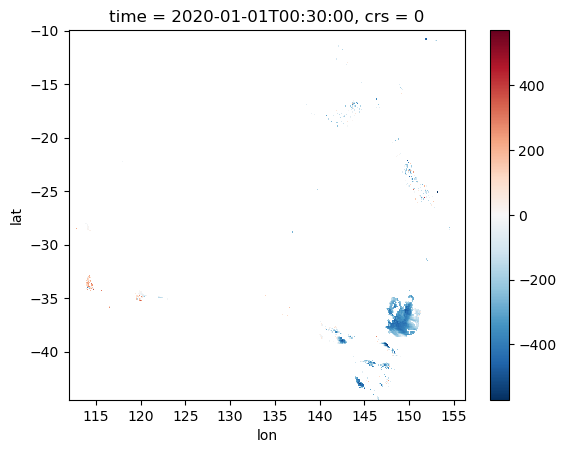

In [12]:
time='2020-01-01T00:30'

xr.where(ds.sel(time=time).ct == 5, ds.ghi_diff.sel(time=time), np.nan).plot()

## Loop over CTs and calculate each of their errors

In [40]:
def ct_rmse(ds, time):
    ds_time = ds.sel(time=time)
    ct_diffs = xr.where(ds_time.ct == ct, ds_time.ghi_diff, np.nan)
    return np.sqrt((ct_diffs**2).mean(dim=['lat', 'lon'], skipna=True))

In [47]:
# Simple resample to get ct data to same resolution
time='2020-01-01'

ds_ct_slice = ds_ct.sel(time=time)
diff_slice = diff.sel(time=time)

rmse = {}
for ct in range(5,6):
    rmse[ct] = ct_rmse(diff_slice, ct=ct).compute().data

2025-09-23 12:14:41,817:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 401.81 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(

2025-09-23 12:14:41,817:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 401.81 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(

This m

In [48]:
rmse

{5: array([203.17434631, 250.89722346, 260.26731935, 261.20768871,
        281.5243791 , 303.11492564, 265.19600714, 169.85499707,
        102.20152206,  98.03933566,  90.57350686,  15.84924396,
         53.85609265,  70.15961844, 111.04925013, 156.11853949,
        192.92647615]),
 6: array([217.78066755, 263.86286241, 315.78897184, 302.2895646 ,
        264.12173948, 268.65382366, 233.02056138, 165.33816294,
        102.20896212,  97.09127652,  73.99232595,  12.62807528,
         44.37977249,  39.14298206,  71.9487223 , 118.15142651,
        169.63037729]),
 7: array([222.86073881, 288.74565929, 374.56084068, 395.37179638,
        374.92916993, 314.50991857, 261.49282547, 201.69994959,
        127.17909905,  84.98317624,  35.62363053,   9.10080096,
         12.28641925,  18.7034287 ,  39.47432945,  98.71887666,
        213.14480831]),
 8: array([259.83952298, 391.53310033, 469.3625454 , 513.28825711,
        458.18142649, 388.24435959, 314.21054967, 234.64805737,
        146.11997879

{'whiskers': [<matplotlib.lines.Line2D at 0x153180e992d0>,
 'caps': [<matplotlib.lines.Line2D at 0x15312398e310>,
 'boxes': [<matplotlib.lines.Line2D at 0x15312b9382d0>,
 'medians': [<matplotlib.lines.Line2D at 0x1531612e6a10>,
 'fliers': [<matplotlib.lines.Line2D at 0x1531f71a7950>,
 'means': []}

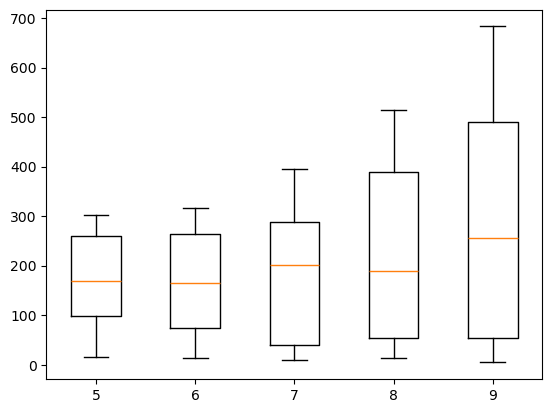

In [54]:
plt.boxplot(rmse.values(), tick_labels=rmse.keys())